In [1]:
import os
import numpy as np
import math
import matplotlib.pyplot as plt

import scipy as sp
import scipy.linalg
import scipy.optimize

# from scipy import optimize

import glob

# # import lsqfit
# from lib import Jackknife
# from lib import simple_mean
# from lib import format_print

# plt.rcParams['figure.dpi'] = 300

In [2]:
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "Helvetica",
    'font.size'  : 20
})

In [3]:
def f(t, nmax, T):
    res = 0.0
    for n in range(1,nmax):
        res += np.sqrt( n*(n+1.0) ) * (2.0*n+1.0) * np.exp( -np.sqrt( n*(n+1.0) )*t )
        res += np.sqrt( n*(n+1.0) ) * (2.0*n+1.0) * np.exp( -np.sqrt( n*(n+1.0) )*(T-t) )
        res += np.sqrt( n*(n+1.0) ) * (2.0*n+1.0) * np.exp( -np.sqrt( n*(n+1.0) )*(t+T) )
        res += np.sqrt( n*(n+1.0) ) * (2.0*n+1.0) * np.exp( -np.sqrt( n*(n+1.0) )*(2*T-t) )
        res += np.sqrt( n*(n+1.0) ) * (2.0*n+1.0) * np.exp( -np.sqrt( n*(n+1.0) )*(t+2*T) )
        res += np.sqrt( n*(n+1.0) ) * (2.0*n+1.0) * np.exp( -np.sqrt( n*(n+1.0) )*(3*T-t) )
    return res/(8.0*np.pi)

In [4]:
gsq=0.050000
beta=1.0/gsq

In [5]:
masses_=[]

In [6]:
T=16
Nt=24 # 240

In [7]:
l1_1 = np.loadtxt("prop_gauge_gsq0.050000_L1_Nt"+str(Nt)+"_T"+str(T)+".000000.dat")
l2_1 = np.loadtxt("prop_gauge_gsq0.050000_L2_Nt"+str(Nt)+"_T"+str(T)+".000000.dat")
l4_1 = np.loadtxt("prop_gauge_gsq0.050000_L4_Nt"+str(Nt)+"_T"+str(T)+".000000.dat")
l8_1 = np.loadtxt("prop_gauge_gsq0.050000_L8_Nt"+str(Nt)+"_T"+str(T)+".000000.dat")

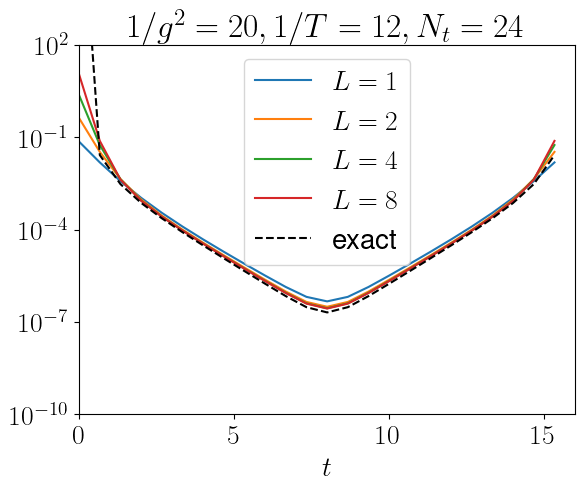

In [8]:
plt.yscale("log")

xx=T * np.arange(Nt)/Nt
plt.plot( xx, l1_1, label="$L=1$" )
plt.plot( xx, l2_1, label="$L=2$" )
plt.plot( xx, l4_1, label="$L=4$" )
plt.plot( xx, l8_1, label="$L=8$" )
# plt.plot( xx, l12_1, label="$L=16$" )

yy= (1.0/beta)*f(xx, 4000, T) # *fixme*
plt.plot( xx, yy, ls='dashed', c='black', label='exact' )

plt.xlabel("$t$")
plt.title("$1/g^2 = 20, 1/T=12, N_t="+str(Nt)+"$")

plt.xlim(0, T)
plt.ylim(1.0e-10, 1.0e2)
plt.legend()

# plt.savefig("jtjt_gaussian.pdf", bbox_inches="tight")

In [9]:
at = T/Nt

fitm = int(4.0 * Nt/T)
fitM = int(7.5 * Nt/T)

def fitter( x, m1, m2, A ):
    return m1 + A * np.exp(-m2*x)

In [10]:
tmp = np.arccosh(l1_1/l1_1[int(Nt/2)])
yy = (-tmp[1:]+tmp[:-1])/at

In [11]:
opt = sp.optimize.curve_fit( fitter, xx[fitm:fitM], yy[fitm:fitM],
                           p0=(np.sqrt(2.0), 1.2, 3. ), 
                           full_output=True, absolute_sigma=True )

(0.0, 2.0)

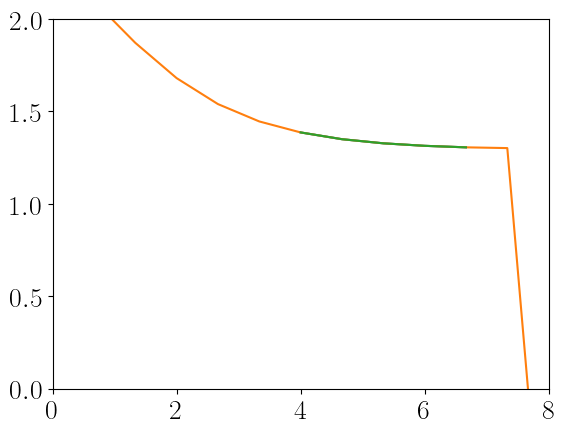

In [12]:
plt.plot( xx[fitm:fitM], yy[fitm:fitM] )
plt.plot( xx[1:2*fitM], yy[1:2*fitM] )

# plt.plot( xx[:-1], np.sqrt(2.0) + 5.2*np.exp(-1.2*xx[:-1]) )
plt.plot( xx[fitm:fitM], fitter(xx[fitm:fitM], opt[0][0], opt[0][1], opt[0][2]) )

plt.xlim(0,T/2)
plt.ylim(0,2)

In [13]:
masses_.append([1, Nt, opt[0][0]])

In [14]:
tmp = np.arccosh(l2_1/l2_1[int(Nt/2)])
yy = (-tmp[1:]+tmp[:-1])/at

In [15]:
opt = sp.optimize.curve_fit( fitter, xx[fitm:fitM], yy[fitm:fitM],
                           p0=(np.sqrt(2.0), 1.2, 3. ), 
                           full_output=True, absolute_sigma=True )

(0.0, 2.0)

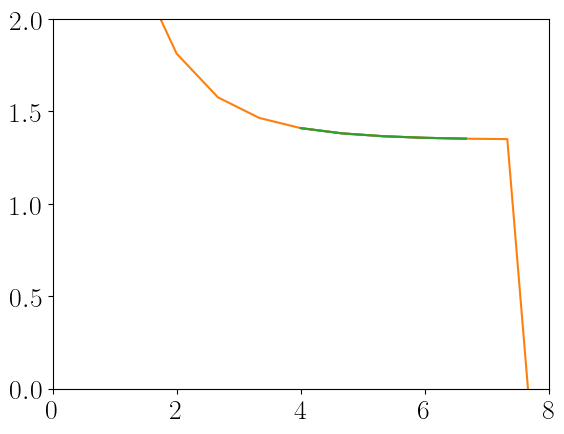

In [16]:
plt.plot( xx[fitm:fitM], yy[fitm:fitM] )
plt.plot( xx[1:2*fitM], yy[1:2*fitM] )

# plt.plot( xx[:-1], np.sqrt(2.0) + 5.2*np.exp(-1.2*xx[:-1]) )
plt.plot( xx[fitm:fitM], fitter(xx[fitm:fitM], opt[0][0], opt[0][1], opt[0][2]) )

plt.xlim(0,T/2)
plt.ylim(0,2)

In [17]:
masses_.append([2, Nt, opt[0][0]])

In [18]:
tmp = np.arccosh(l4_1/l4_1[int(Nt/2)])
yy = (-tmp[1:]+tmp[:-1])/at

In [19]:
opt = sp.optimize.curve_fit( fitter, xx[fitm:fitM], yy[fitm:fitM],
                           p0=(np.sqrt(2.0), 1.2, 3. ), 
                           full_output=True, absolute_sigma=True )

(0.0, 2.0)

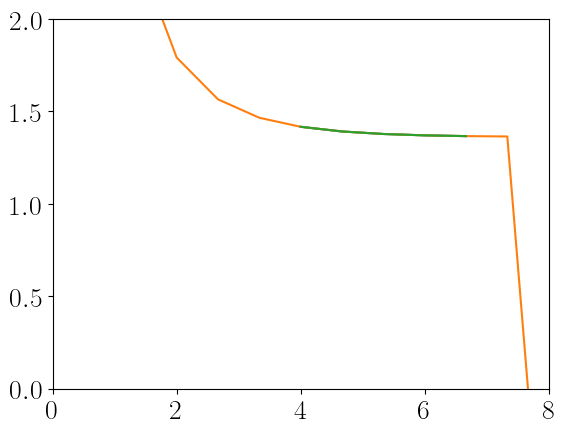

In [20]:
plt.plot( xx[fitm:fitM], yy[fitm:fitM] )
plt.plot( xx[1:2*fitM], yy[1:2*fitM] )

# plt.plot( xx[:-1], np.sqrt(2.0) + 5.2*np.exp(-1.2*xx[:-1]) )
plt.plot( xx[fitm:fitM], fitter(xx[fitm:fitM], opt[0][0], opt[0][1], opt[0][2]) )

plt.xlim(0,T/2)
plt.ylim(0,2)

In [21]:
masses_.append([4, Nt, opt[0][0]])

In [22]:
tmp = np.arccosh(l8_1/l8_1[int(Nt/2)])
yy = (-tmp[1:]+tmp[:-1])/at

In [23]:
opt = sp.optimize.curve_fit( fitter, xx[fitm:fitM], yy[fitm:fitM],
                           p0=(np.sqrt(2.0), 1.2, 3. ), 
                           full_output=True, absolute_sigma=True )

(0.0, 2.0)

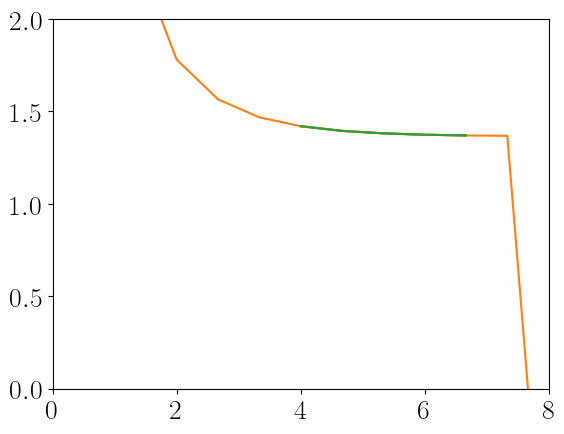

In [24]:
plt.plot( xx[fitm:fitM], yy[fitm:fitM] )
plt.plot( xx[1:2*fitM], yy[1:2*fitM] )

# plt.plot( xx[:-1], np.sqrt(2.0) + 5.2*np.exp(-1.2*xx[:-1]) )
plt.plot( xx[fitm:fitM], fitter(xx[fitm:fitM], opt[0][0], opt[0][1], opt[0][2]) )

plt.xlim(0,T/2)
plt.ylim(0,2)

In [25]:
masses_.append([8, Nt, opt[0][0]])

In [26]:
T=16
Nt=48 # 240

In [27]:
l1_1 = np.loadtxt("prop_gauge_gsq0.050000_L1_Nt"+str(Nt)+"_T"+str(T)+".000000.dat")
l2_1 = np.loadtxt("prop_gauge_gsq0.050000_L2_Nt"+str(Nt)+"_T"+str(T)+".000000.dat")
l4_1 = np.loadtxt("prop_gauge_gsq0.050000_L4_Nt"+str(Nt)+"_T"+str(T)+".000000.dat")
l8_1 = np.loadtxt("prop_gauge_gsq0.050000_L8_Nt"+str(Nt)+"_T"+str(T)+".000000.dat")

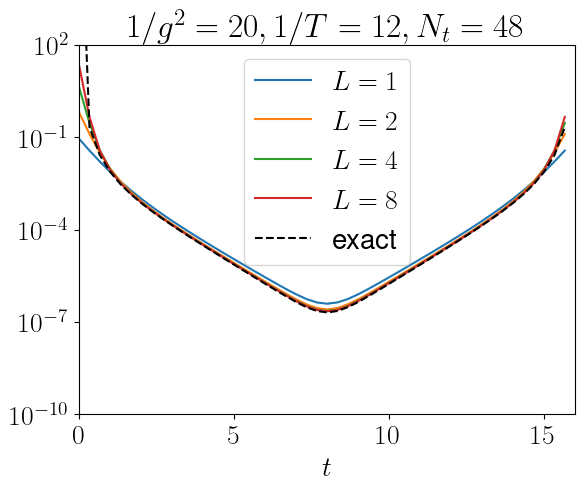

In [28]:
plt.yscale("log")

xx=T * np.arange(Nt)/Nt
plt.plot( xx, l1_1, label="$L=1$" )
plt.plot( xx, l2_1, label="$L=2$" )
plt.plot( xx, l4_1, label="$L=4$" )
plt.plot( xx, l8_1, label="$L=8$" )
# plt.plot( xx, l12_1, label="$L=16$" )

yy= (1.0/beta)*f(xx, 4000, T) # *fixme*
plt.plot( xx, yy, ls='dashed', c='black', label='exact' )

plt.xlabel("$t$")
plt.title("$1/g^2 = 20, 1/T=12, N_t="+str(Nt)+"$")

plt.xlim(0, T)
plt.ylim(1.0e-10, 1.0e2)
plt.legend()

# plt.savefig("jtjt_gaussian.pdf", bbox_inches="tight")

In [29]:
at = T/Nt

fitm = int(4.0 * Nt/T)
fitM = int(7.5 * Nt/T)

def fitter( x, m1, m2, A ):
    return m1 + A * np.exp(-m2*x)

In [30]:
tmp = np.arccosh(l1_1/l1_1[int(Nt/2)])
yy = (-tmp[1:]+tmp[:-1])/at

In [31]:
opt = sp.optimize.curve_fit( fitter, xx[fitm:fitM], yy[fitm:fitM],
                           p0=(np.sqrt(2.0), 1.2, 3. ), 
                           full_output=True, absolute_sigma=True )

(0.0, 2.0)

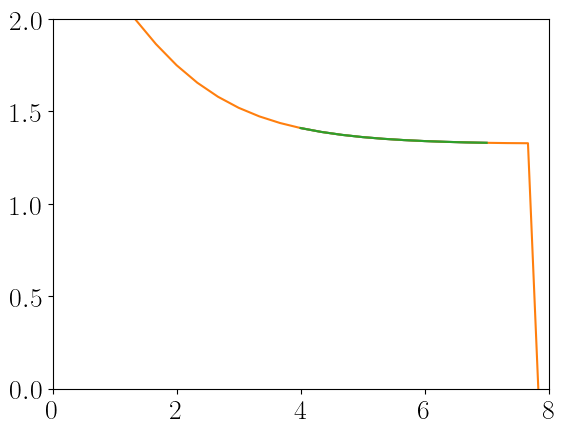

In [32]:
plt.plot( xx[fitm:fitM], yy[fitm:fitM] )
plt.plot( xx[1:2*fitM], yy[1:2*fitM] )

# plt.plot( xx[:-1], np.sqrt(2.0) + 5.2*np.exp(-1.2*xx[:-1]) )
plt.plot( xx[fitm:fitM], fitter(xx[fitm:fitM], opt[0][0], opt[0][1], opt[0][2]) )

plt.xlim(0,T/2)
plt.ylim(0,2)

In [33]:
masses_.append([1, Nt, opt[0][0]])

In [34]:
tmp = np.arccosh(l2_1/l2_1[int(Nt/2)])
yy = (-tmp[1:]+tmp[:-1])/at

In [35]:
opt = sp.optimize.curve_fit( fitter, xx[fitm:fitM], yy[fitm:fitM],
                           p0=(np.sqrt(2.0), 1.2, 3. ), 
                           full_output=True, absolute_sigma=True )

(0.0, 2.0)

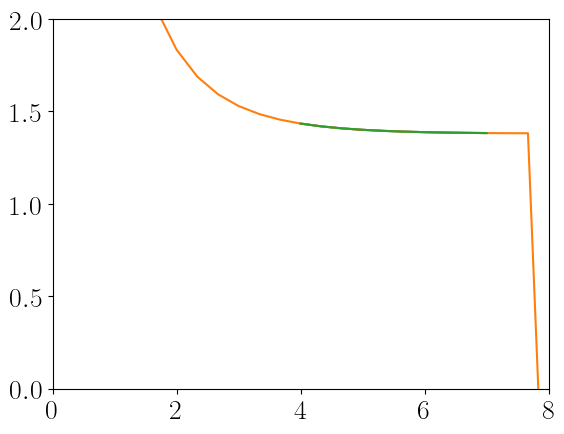

In [36]:
plt.plot( xx[fitm:fitM], yy[fitm:fitM] )
plt.plot( xx[1:2*fitM], yy[1:2*fitM] )

# plt.plot( xx[:-1], np.sqrt(2.0) + 5.2*np.exp(-1.2*xx[:-1]) )
plt.plot( xx[fitm:fitM], fitter(xx[fitm:fitM], opt[0][0], opt[0][1], opt[0][2]) )

plt.xlim(0,T/2)
plt.ylim(0,2)

In [37]:
masses_.append([2, Nt, opt[0][0]])

In [38]:
tmp = np.arccosh(l4_1/l4_1[int(Nt/2)])
yy = (-tmp[1:]+tmp[:-1])/at

In [39]:
opt = sp.optimize.curve_fit( fitter, xx[fitm:fitM], yy[fitm:fitM],
                           p0=(np.sqrt(2.0), 1.2, 3. ), 
                           full_output=True, absolute_sigma=True )

(0.0, 2.0)

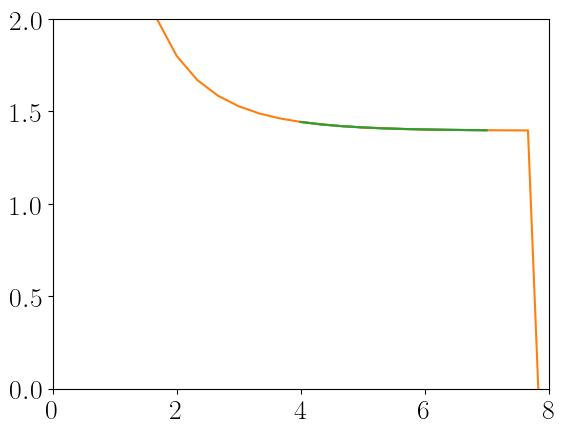

In [40]:
plt.plot( xx[fitm:fitM], yy[fitm:fitM] )
plt.plot( xx[1:2*fitM], yy[1:2*fitM] )

# plt.plot( xx[:-1], np.sqrt(2.0) + 5.2*np.exp(-1.2*xx[:-1]) )
plt.plot( xx[fitm:fitM], fitter(xx[fitm:fitM], opt[0][0], opt[0][1], opt[0][2]) )

plt.xlim(0,T/2)
plt.ylim(0,2)

In [41]:
masses_.append([4, Nt, opt[0][0]])

In [42]:
tmp = np.arccosh(l8_1/l8_1[int(Nt/2)])
yy = (-tmp[1:]+tmp[:-1])/at

In [43]:
opt = sp.optimize.curve_fit( fitter, xx[fitm:fitM], yy[fitm:fitM],
                           p0=(np.sqrt(2.0), 1.2, 3. ), 
                           full_output=True, absolute_sigma=True )

(0.0, 2.0)

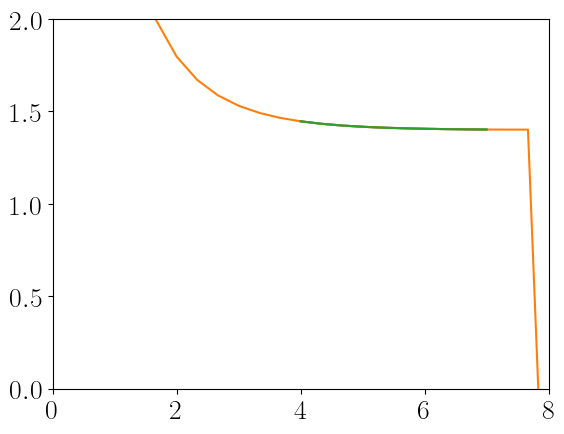

In [44]:
plt.plot( xx[fitm:fitM], yy[fitm:fitM] )
plt.plot( xx[1:2*fitM], yy[1:2*fitM] )

# plt.plot( xx[:-1], np.sqrt(2.0) + 5.2*np.exp(-1.2*xx[:-1]) )
plt.plot( xx[fitm:fitM], fitter(xx[fitm:fitM], opt[0][0], opt[0][1], opt[0][2]) )

plt.xlim(0,T/2)
plt.ylim(0,2)

In [45]:
masses_.append([8, Nt, opt[0][0]])

In [46]:
T=16
Nt=64 # 240

In [47]:
l1_1 = np.loadtxt("prop_gauge_gsq0.050000_L1_Nt"+str(Nt)+"_T"+str(T)+".000000.dat")
l2_1 = np.loadtxt("prop_gauge_gsq0.050000_L2_Nt"+str(Nt)+"_T"+str(T)+".000000.dat")
l4_1 = np.loadtxt("prop_gauge_gsq0.050000_L4_Nt"+str(Nt)+"_T"+str(T)+".000000.dat")
l8_1 = np.loadtxt("prop_gauge_gsq0.050000_L8_Nt"+str(Nt)+"_T"+str(T)+".000000.dat")

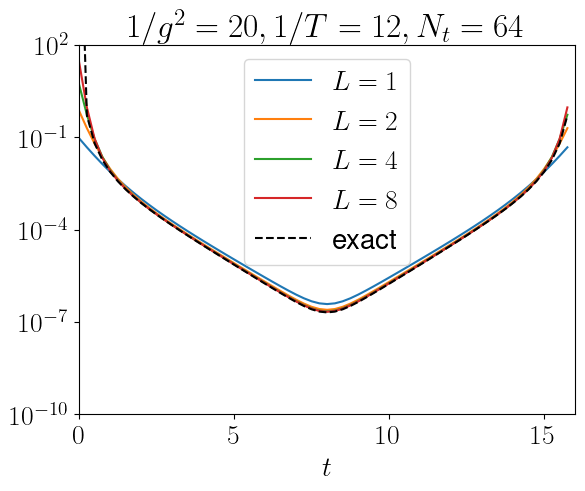

In [48]:
plt.yscale("log")

xx=T * np.arange(Nt)/Nt
plt.plot( xx, l1_1, label="$L=1$" )
plt.plot( xx, l2_1, label="$L=2$" )
plt.plot( xx, l4_1, label="$L=4$" )
plt.plot( xx, l8_1, label="$L=8$" )
# plt.plot( xx, l12_1, label="$L=16$" )

yy= (1.0/beta)*f(xx, 4000, T) # *fixme*
plt.plot( xx, yy, ls='dashed', c='black', label='exact' )

plt.xlabel("$t$")
plt.title("$1/g^2 = 20, 1/T=12, N_t="+str(Nt)+"$")

plt.xlim(0, T)
plt.ylim(1.0e-10, 1.0e2)
plt.legend()

# plt.savefig("jtjt_gaussian.pdf", bbox_inches="tight")

In [49]:
at = T/Nt

fitm = int(4.0 * Nt/T)
fitM = int(7.5 * Nt/T)

def fitter( x, m1, m2, A ):
    return m1 + A * np.exp(-m2*x)

In [50]:
tmp = np.arccosh(l1_1/l1_1[int(Nt/2)])
yy = (-tmp[1:]+tmp[:-1])/at

In [51]:
opt = sp.optimize.curve_fit( fitter, xx[fitm:fitM], yy[fitm:fitM],
                           p0=(np.sqrt(2.0), 1.2, 3. ), 
                           full_output=True, absolute_sigma=True )

(0.0, 2.0)

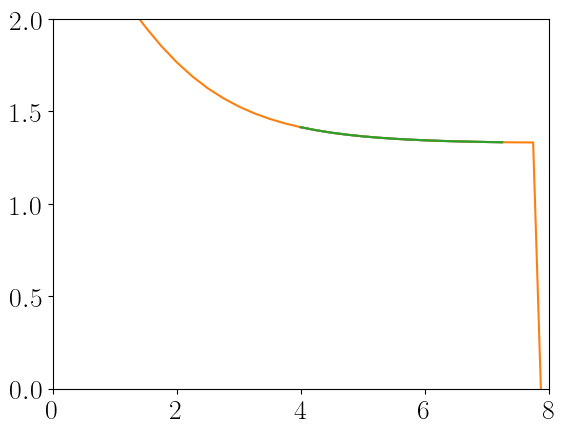

In [52]:
plt.plot( xx[fitm:fitM], yy[fitm:fitM] )
plt.plot( xx[1:2*fitM], yy[1:2*fitM] )

# plt.plot( xx[:-1], np.sqrt(2.0) + 5.2*np.exp(-1.2*xx[:-1]) )
plt.plot( xx[fitm:fitM], fitter(xx[fitm:fitM], opt[0][0], opt[0][1], opt[0][2]) )

plt.xlim(0,T/2)
plt.ylim(0,2)

In [53]:
masses_.append([1, Nt, opt[0][0]])

In [54]:
tmp = np.arccosh(l2_1/l2_1[int(Nt/2)])
yy = (-tmp[1:]+tmp[:-1])/at

In [55]:
opt = sp.optimize.curve_fit( fitter, xx[fitm:fitM], yy[fitm:fitM],
                           p0=(np.sqrt(2.0), 1.2, 3. ), 
                           full_output=True, absolute_sigma=True )

(0.0, 2.0)

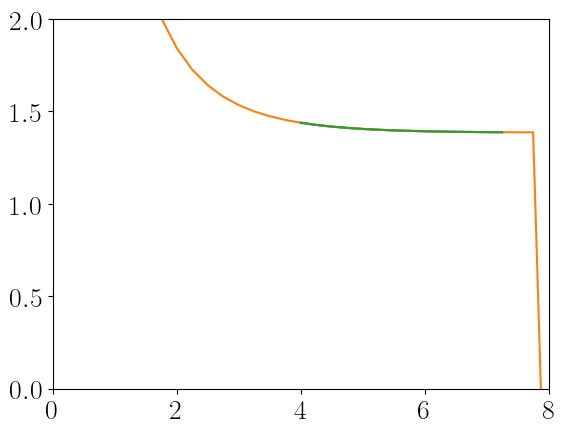

In [56]:
plt.plot( xx[fitm:fitM], yy[fitm:fitM] )
plt.plot( xx[1:2*fitM], yy[1:2*fitM] )

# plt.plot( xx[:-1], np.sqrt(2.0) + 5.2*np.exp(-1.2*xx[:-1]) )
plt.plot( xx[fitm:fitM], fitter(xx[fitm:fitM], opt[0][0], opt[0][1], opt[0][2]) )

plt.xlim(0,T/2)
plt.ylim(0,2)

In [57]:
masses_.append([2, Nt, opt[0][0]])

In [58]:
tmp = np.arccosh(l4_1/l4_1[int(Nt/2)])
yy = (-tmp[1:]+tmp[:-1])/at

In [59]:
opt = sp.optimize.curve_fit( fitter, xx[fitm:fitM], yy[fitm:fitM],
                           p0=(np.sqrt(2.0), 1.2, 3. ), 
                           full_output=True, absolute_sigma=True )

(0.0, 2.0)

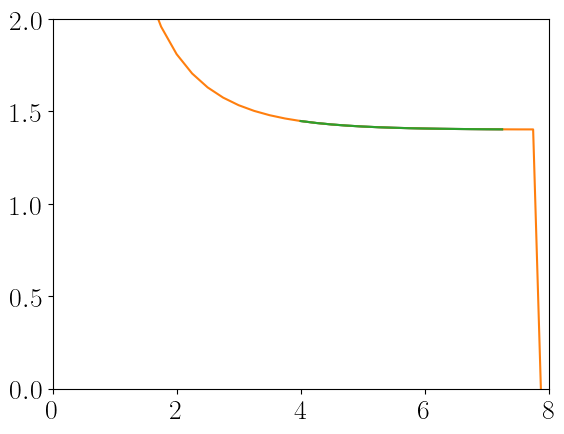

In [60]:
plt.plot( xx[fitm:fitM], yy[fitm:fitM] )
plt.plot( xx[1:2*fitM], yy[1:2*fitM] )

# plt.plot( xx[:-1], np.sqrt(2.0) + 5.2*np.exp(-1.2*xx[:-1]) )
plt.plot( xx[fitm:fitM], fitter(xx[fitm:fitM], opt[0][0], opt[0][1], opt[0][2]) )

plt.xlim(0,T/2)
plt.ylim(0,2)

In [61]:
masses_.append([4, Nt, opt[0][0]])

In [62]:
tmp = np.arccosh(l8_1/l8_1[int(Nt/2)])
yy = (-tmp[1:]+tmp[:-1])/at

In [63]:
opt = sp.optimize.curve_fit( fitter, xx[fitm:fitM], yy[fitm:fitM],
                           p0=(np.sqrt(2.0), 1.2, 3. ), 
                           full_output=True, absolute_sigma=True )

(0.0, 2.0)

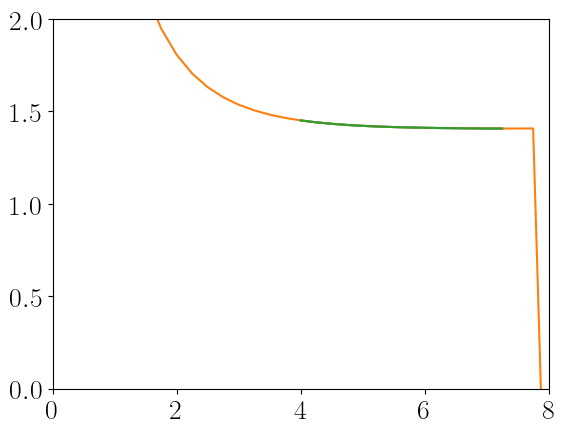

In [64]:
plt.plot( xx[fitm:fitM], yy[fitm:fitM] )
plt.plot( xx[1:2*fitM], yy[1:2*fitM] )

# plt.plot( xx[:-1], np.sqrt(2.0) + 5.2*np.exp(-1.2*xx[:-1]) )
plt.plot( xx[fitm:fitM], fitter(xx[fitm:fitM], opt[0][0], opt[0][1], opt[0][2]) )

plt.xlim(0,T/2)
plt.ylim(0,2)

In [65]:
masses_.append([8, Nt, opt[0][0]])

In [66]:
T=16
Nt=96 # 240

In [67]:
l1_1 = np.loadtxt("prop_gauge_gsq0.050000_L1_Nt"+str(Nt)+"_T"+str(T)+".000000.dat")
l2_1 = np.loadtxt("prop_gauge_gsq0.050000_L2_Nt"+str(Nt)+"_T"+str(T)+".000000.dat")
l4_1 = np.loadtxt("prop_gauge_gsq0.050000_L4_Nt"+str(Nt)+"_T"+str(T)+".000000.dat")
l8_1 = np.loadtxt("prop_gauge_gsq0.050000_L8_Nt"+str(Nt)+"_T"+str(T)+".000000.dat")

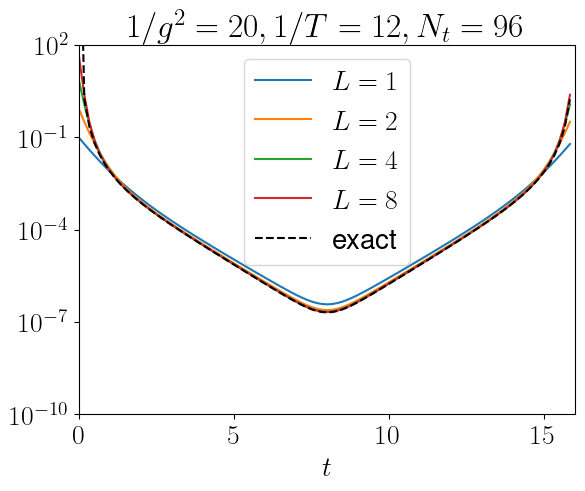

In [68]:
plt.yscale("log")

xx=T * np.arange(Nt)/Nt
plt.plot( xx, l1_1, label="$L=1$" )
plt.plot( xx, l2_1, label="$L=2$" )
plt.plot( xx, l4_1, label="$L=4$" )
plt.plot( xx, l8_1, label="$L=8$" )
# plt.plot( xx, l12_1, label="$L=16$" )

yy= (1.0/beta)*f(xx, 4000, T) # *fixme*
plt.plot( xx, yy, ls='dashed', c='black', label='exact' )

plt.xlabel("$t$")
plt.title("$1/g^2 = 20, 1/T=12, N_t="+str(Nt)+"$")

plt.xlim(0, T)
plt.ylim(1.0e-10, 1.0e2)
plt.legend()

# plt.savefig("jtjt_gaussian.pdf", bbox_inches="tight")

In [69]:
at = T/Nt

fitm = int(4.0 * Nt/T)
fitM = int(7.5 * Nt/T)

def fitter( x, m1, m2, A ):
    return m1 + A * np.exp(-m2*x)

In [70]:
tmp = np.arccosh(l1_1/l1_1[int(Nt/2)])
yy = (-tmp[1:]+tmp[:-1])/at

In [71]:
opt = sp.optimize.curve_fit( fitter, xx[fitm:fitM], yy[fitm:fitM],
                           p0=(np.sqrt(2.0), 1.2, 3. ), 
                           full_output=True, absolute_sigma=True )

(0.0, 2.0)

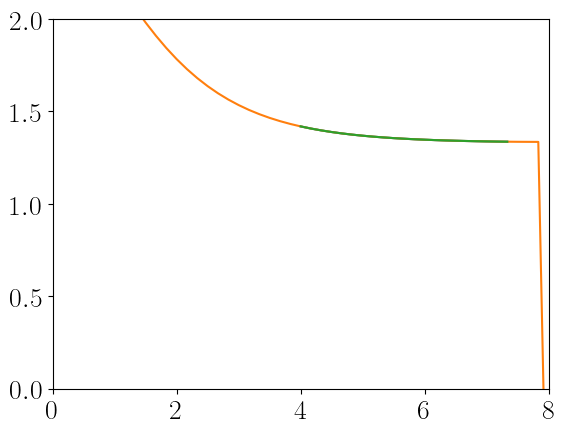

In [72]:
plt.plot( xx[fitm:fitM], yy[fitm:fitM] )
plt.plot( xx[1:2*fitM], yy[1:2*fitM] )

# plt.plot( xx[:-1], np.sqrt(2.0) + 5.2*np.exp(-1.2*xx[:-1]) )
plt.plot( xx[fitm:fitM], fitter(xx[fitm:fitM], opt[0][0], opt[0][1], opt[0][2]) )

plt.xlim(0,T/2)
plt.ylim(0,2)

In [73]:
masses_.append([1, Nt, opt[0][0]])

In [74]:
tmp = np.arccosh(l2_1/l2_1[int(Nt/2)])
yy = (-tmp[1:]+tmp[:-1])/at

In [75]:
opt = sp.optimize.curve_fit( fitter, xx[fitm:fitM], yy[fitm:fitM],
                           p0=(np.sqrt(2.0), 1.2, 3. ), 
                           full_output=True, absolute_sigma=True )

(0.0, 2.0)

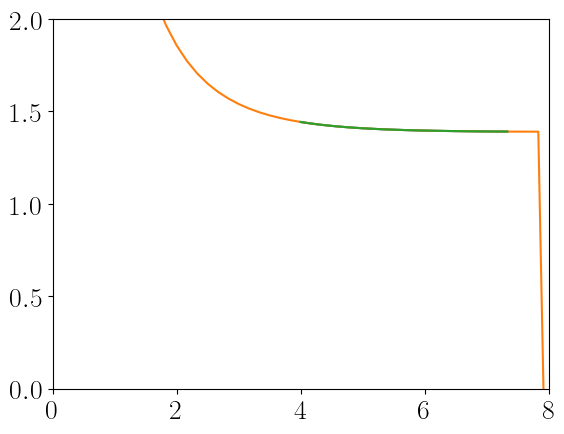

In [76]:
plt.plot( xx[fitm:fitM], yy[fitm:fitM] )
plt.plot( xx[1:2*fitM], yy[1:2*fitM] )

# plt.plot( xx[:-1], np.sqrt(2.0) + 5.2*np.exp(-1.2*xx[:-1]) )
plt.plot( xx[fitm:fitM], fitter(xx[fitm:fitM], opt[0][0], opt[0][1], opt[0][2]) )

plt.xlim(0,T/2)
plt.ylim(0,2)

In [77]:
masses_.append([2, Nt, opt[0][0]])

In [78]:
tmp = np.arccosh(l4_1/l4_1[int(Nt/2)])
yy = (-tmp[1:]+tmp[:-1])/at

In [79]:
opt = sp.optimize.curve_fit( fitter, xx[fitm:fitM], yy[fitm:fitM],
                           p0=(np.sqrt(2.0), 1.2, 3. ), 
                           full_output=True, absolute_sigma=True )

(0.0, 2.0)

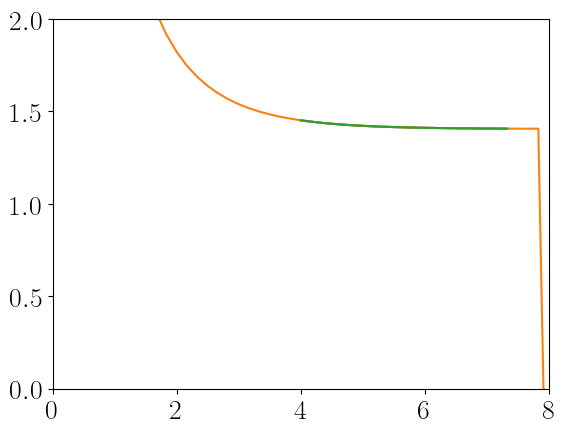

In [80]:
plt.plot( xx[fitm:fitM], yy[fitm:fitM] )
plt.plot( xx[1:2*fitM], yy[1:2*fitM] )

# plt.plot( xx[:-1], np.sqrt(2.0) + 5.2*np.exp(-1.2*xx[:-1]) )
plt.plot( xx[fitm:fitM], fitter(xx[fitm:fitM], opt[0][0], opt[0][1], opt[0][2]) )

plt.xlim(0,T/2)
plt.ylim(0,2)

In [81]:
masses_.append([4, Nt, opt[0][0]])

In [82]:
tmp = np.arccosh(l8_1/l8_1[int(Nt/2)])
yy = (-tmp[1:]+tmp[:-1])/at

In [83]:
opt = sp.optimize.curve_fit( fitter, xx[fitm:fitM], yy[fitm:fitM],
                           p0=(np.sqrt(2.0), 1.2, 3. ), 
                           full_output=True, absolute_sigma=True )

(0.0, 2.0)

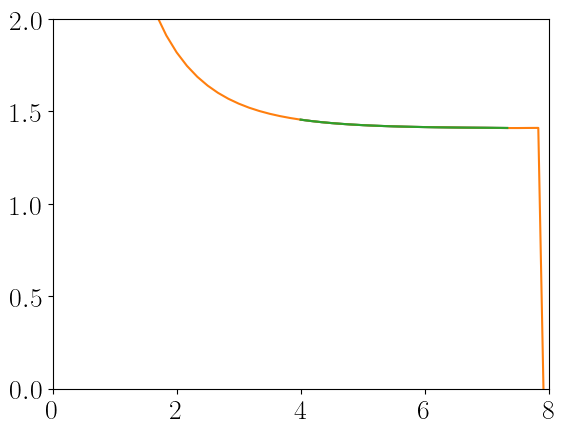

In [84]:
plt.plot( xx[fitm:fitM], yy[fitm:fitM] )
plt.plot( xx[1:2*fitM], yy[1:2*fitM] )

# plt.plot( xx[:-1], np.sqrt(2.0) + 5.2*np.exp(-1.2*xx[:-1]) )
plt.plot( xx[fitm:fitM], fitter(xx[fitm:fitM], opt[0][0], opt[0][1], opt[0][2]) )

plt.xlim(0,T/2)
plt.ylim(0,2)

In [85]:
masses_.append([8, Nt, opt[0][0]])

In [86]:
T=16
Nt=120 # 240

In [87]:
l1_1 = np.loadtxt("prop_gauge_gsq0.050000_L1_Nt"+str(Nt)+"_T"+str(T)+".000000.dat")
l2_1 = np.loadtxt("prop_gauge_gsq0.050000_L2_Nt"+str(Nt)+"_T"+str(T)+".000000.dat")
l4_1 = np.loadtxt("prop_gauge_gsq0.050000_L4_Nt"+str(Nt)+"_T"+str(T)+".000000.dat")
l8_1 = np.loadtxt("prop_gauge_gsq0.050000_L8_Nt"+str(Nt)+"_T"+str(T)+".000000.dat")

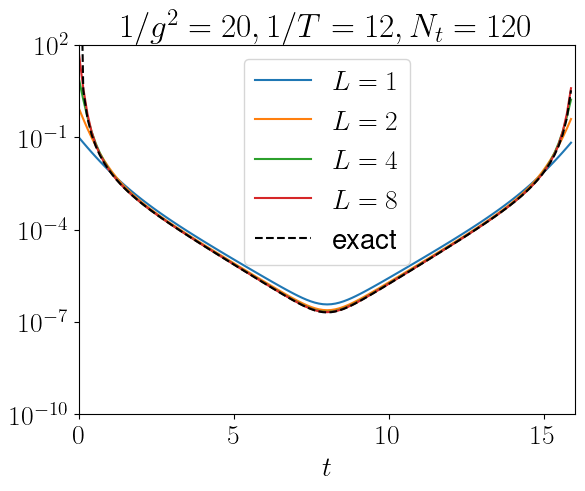

In [88]:
plt.yscale("log")

xx=T * np.arange(Nt)/Nt
plt.plot( xx, l1_1, label="$L=1$" )
plt.plot( xx, l2_1, label="$L=2$" )
plt.plot( xx, l4_1, label="$L=4$" )
plt.plot( xx, l8_1, label="$L=8$" )
# plt.plot( xx, l12_1, label="$L=16$" )

yy= (1.0/beta)*f(xx, 4000, T) # *fixme*
plt.plot( xx, yy, ls='dashed', c='black', label='exact' )

plt.xlabel("$t$")
plt.title("$1/g^2 = 20, 1/T=12, N_t="+str(Nt)+"$")

plt.xlim(0, T)
plt.ylim(1.0e-10, 1.0e2)
plt.legend()

# plt.savefig("jtjt_gaussian.pdf", bbox_inches="tight")

In [89]:
at = T/Nt

fitm = int(4.0 * Nt/T)
fitM = int(7.5 * Nt/T)

def fitter( x, m1, m2, A ):
    return m1 + A * np.exp(-m2*x)

In [90]:
tmp = np.arccosh(l1_1/l1_1[int(Nt/2)])
yy = (-tmp[1:]+tmp[:-1])/at

In [91]:
opt = sp.optimize.curve_fit( fitter, xx[fitm:fitM], yy[fitm:fitM],
                           p0=(np.sqrt(2.0), 1.2, 3. ), 
                           full_output=True, absolute_sigma=True )

(0.0, 2.0)

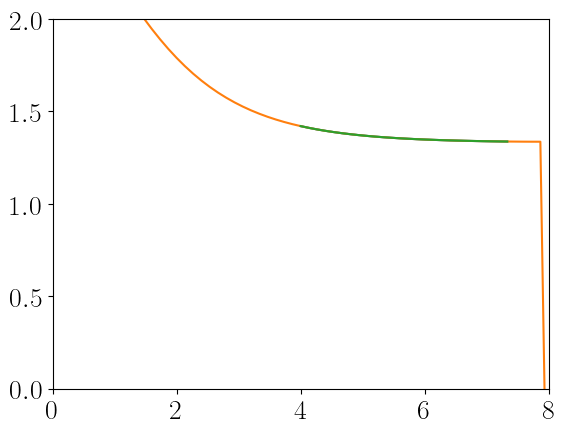

In [92]:
plt.plot( xx[fitm:fitM], yy[fitm:fitM] )
plt.plot( xx[1:2*fitM], yy[1:2*fitM] )

# plt.plot( xx[:-1], np.sqrt(2.0) + 5.2*np.exp(-1.2*xx[:-1]) )
plt.plot( xx[fitm:fitM], fitter(xx[fitm:fitM], opt[0][0], opt[0][1], opt[0][2]) )

plt.xlim(0,T/2)
plt.ylim(0,2)

In [93]:
masses_.append([1, Nt, opt[0][0]])

In [94]:
tmp = np.arccosh(l2_1/l2_1[int(Nt/2)])
yy = (-tmp[1:]+tmp[:-1])/at

In [95]:
opt = sp.optimize.curve_fit( fitter, xx[fitm:fitM], yy[fitm:fitM],
                           p0=(np.sqrt(2.0), 1.2, 3. ), 
                           full_output=True, absolute_sigma=True )

(0.0, 2.0)

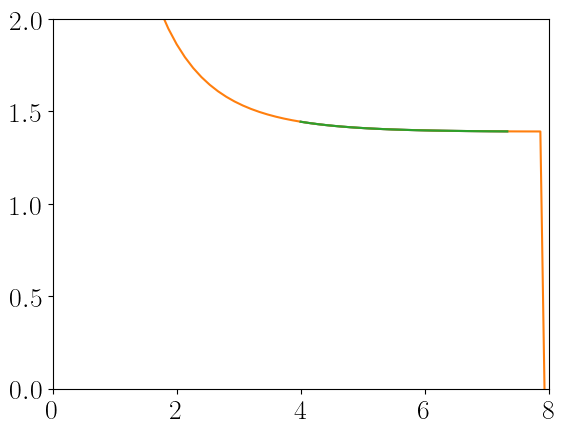

In [96]:
plt.plot( xx[fitm:fitM], yy[fitm:fitM] )
plt.plot( xx[1:2*fitM], yy[1:2*fitM] )

# plt.plot( xx[:-1], np.sqrt(2.0) + 5.2*np.exp(-1.2*xx[:-1]) )
plt.plot( xx[fitm:fitM], fitter(xx[fitm:fitM], opt[0][0], opt[0][1], opt[0][2]) )

plt.xlim(0,T/2)
plt.ylim(0,2)

In [97]:
masses_.append([2, Nt, opt[0][0]])

In [98]:
tmp = np.arccosh(l4_1/l4_1[int(Nt/2)])
yy = (-tmp[1:]+tmp[:-1])/at

In [99]:
opt = sp.optimize.curve_fit( fitter, xx[fitm:fitM], yy[fitm:fitM],
                           p0=(np.sqrt(2.0), 1.2, 3. ), 
                           full_output=True, absolute_sigma=True )

(0.0, 2.0)

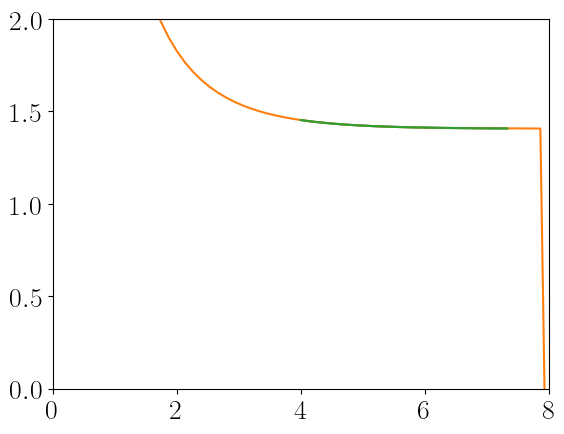

In [100]:
plt.plot( xx[fitm:fitM], yy[fitm:fitM] )
plt.plot( xx[1:2*fitM], yy[1:2*fitM] )

# plt.plot( xx[:-1], np.sqrt(2.0) + 5.2*np.exp(-1.2*xx[:-1]) )
plt.plot( xx[fitm:fitM], fitter(xx[fitm:fitM], opt[0][0], opt[0][1], opt[0][2]) )

plt.xlim(0,T/2)
plt.ylim(0,2)

In [101]:
masses_.append([4, Nt, opt[0][0]])

In [102]:
tmp = np.arccosh(l8_1/l8_1[int(Nt/2)])
yy = (-tmp[1:]+tmp[:-1])/at

In [103]:
opt = sp.optimize.curve_fit( fitter, xx[fitm:fitM], yy[fitm:fitM],
                           p0=(np.sqrt(2.0), 1.2, 3. ), 
                           full_output=True, absolute_sigma=True )

(0.0, 2.0)

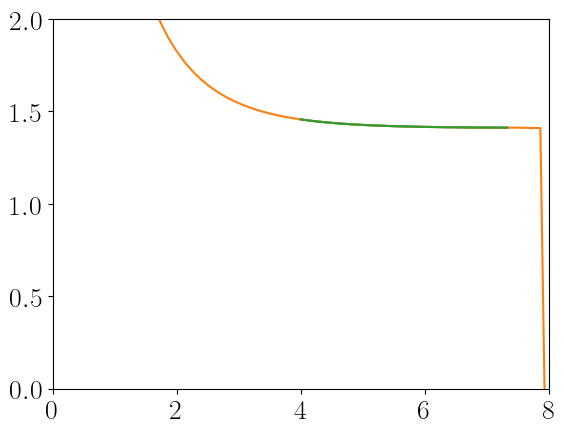

In [104]:
plt.plot( xx[fitm:fitM], yy[fitm:fitM] )
plt.plot( xx[1:2*fitM], yy[1:2*fitM] )

# plt.plot( xx[:-1], np.sqrt(2.0) + 5.2*np.exp(-1.2*xx[:-1]) )
plt.plot( xx[fitm:fitM], fitter(xx[fitm:fitM], opt[0][0], opt[0][1], opt[0][2]) )

plt.xlim(0,T/2)
plt.ylim(0,2)

In [105]:
masses_.append([8, Nt, opt[0][0]])

In [106]:
masses = np.array(masses_)

In [107]:
ells={1:1.107148717794090e+00, 
      2:5.909464448075019e-01, 
      4:2.994744726728921e-01,
      8:1.502274914280941e-01, 
      12:1.002118985797942e-01
     }

In [108]:
masses

array([[  1.        ,  24.        ,   1.2930765 ],
       [  2.        ,  24.        ,   1.34714289],
       [  4.        ,  24.        ,   1.36185637],
       [  8.        ,  24.        ,   1.36543225],
       [  1.        ,  48.        ,   1.32292346],
       [  2.        ,  48.        ,   1.38021437],
       [  4.        ,  48.        ,   1.39618512],
       [  8.        ,  48.        ,   1.39994269],
       [  1.        ,  64.        ,   1.32765725],
       [  2.        ,  64.        ,   1.38544135],
       [  4.        ,  64.        ,   1.40159164],
       [  8.        ,  64.        ,   1.40573155],
       [  1.        ,  96.        ,   1.33102841],
       [  2.        ,  96.        ,   1.38922118],
       [  4.        ,  96.        ,   1.4055004 ],
       [  8.        ,  96.        ,   1.40947169],
       [  1.        , 120.        ,   1.33197963],
       [  2.        , 120.        ,   1.39031766],
       [  4.        , 120.        ,   1.40667848],
       [  8.        , 120.     

In [109]:
a_s = np.array([ [ ells[elem[0]], T/elem[1] ] for elem in masses ])

In [110]:
def fitter( x, c0, cx, ct ):
    return c0 + cx*x[0]**2 + ct*x[1]**2

In [111]:
opt1= sp.optimize.curve_fit( fitter, a_s.T, masses.T[2],
                       p0=(np.sqrt(2.0), 0.0, 0.0 ), 
                       full_output=True, absolute_sigma=True )

In [112]:
opt1

(array([ 1.41350845, -0.06416096, -0.10050911]),
 array([[ 0.12335519, -0.0915654 , -0.26168765],
        [-0.0915654 ,  0.21707615,  0.        ],
        [-0.26168765,  0.        ,  1.97169409]]),
 {'fvec': array([-2.88588511e-03, -7.11298429e-04,  1.22709161e-03,  1.95747515e-03,
          7.70193777e-04, -2.79745534e-04,  4.01379499e-04,  9.50072024e-04,
          9.22263175e-04, -6.20865007e-04, -1.19282728e-04,  4.70765384e-05,
          1.04099928e-03, -9.10796207e-04, -5.38147503e-04, -2.03161788e-04,
          1.09487455e-03, -1.00218688e-03, -7.11138468e-04, -4.28917938e-04]),
  'nfev': 9,
  'fjac': array([[-4.47213595,  0.2236068 ,  0.2236068 ,  0.2236068 ,  0.2236068 ,
           0.2236068 ,  0.2236068 ,  0.2236068 ,  0.2236068 ,  0.2236068 ,
           0.2236068 ,  0.2236068 ,  0.2236068 ,  0.2236068 ,  0.2236068 ,
           0.2236068 ,  0.2236068 ,  0.2236068 ,  0.2236068 ,  0.2236068 ],
         [-1.88640218,  2.14631739,  0.22319499,  0.25446562, -0.30612716,
          

In [113]:
masses2_ = []
for elem in masses:
    if elem[0]!=1:
        masses2_.append(elem)
masses2=np.array(masses2_)

In [114]:
masses2

array([[  2.        ,  24.        ,   1.34714289],
       [  4.        ,  24.        ,   1.36185637],
       [  8.        ,  24.        ,   1.36543225],
       [  2.        ,  48.        ,   1.38021437],
       [  4.        ,  48.        ,   1.39618512],
       [  8.        ,  48.        ,   1.39994269],
       [  2.        ,  64.        ,   1.38544135],
       [  4.        ,  64.        ,   1.40159164],
       [  8.        ,  64.        ,   1.40573155],
       [  2.        ,  96.        ,   1.38922118],
       [  4.        ,  96.        ,   1.4055004 ],
       [  8.        ,  96.        ,   1.40947169],
       [  2.        , 120.        ,   1.39031766],
       [  4.        , 120.        ,   1.40667848],
       [  8.        , 120.        ,   1.41070253]])

In [115]:
a_s2 = np.array([ [ ells[elem[0]], T/elem[1] ] for elem in masses2 ])

In [116]:
opt2= sp.optimize.curve_fit( fitter, a_s2.T, masses2.T[2],
                       p0=(np.sqrt(2.0), 0.0, 0.0 ), 
                       full_output=True, absolute_sigma=True )

In [117]:
opt2

(array([ 1.41347342, -0.06076631, -0.10370615]),
 array([[ 1.92483407e-01, -5.16875730e-01, -3.48916968e-01],
        [-5.16875730e-01,  3.36018409e+00, -3.78044163e-16],
        [-3.48916968e-01, -3.78044163e-16,  2.62892646e+00]]),
 {'fvec': array([-9.81760018e-04,  7.56060016e-05,  5.78151651e-04,  5.15470948e-04,
          3.15571959e-04,  6.36426600e-04,  3.29762860e-04, -4.96788832e-05,
         -1.11157500e-04,  1.50839792e-04, -3.57535525e-04, -2.50387694e-04,
          9.14194583e-05, -4.98556148e-04, -4.44173502e-04]),
  'nfev': 9,
  'fjac': array([[-3.87298333e+00,  2.58198890e-01,  2.58198890e-01,
           2.58198890e-01,  2.58198890e-01,  2.58198890e-01,
           2.58198890e-01,  2.58198890e-01,  2.58198890e-01,
           2.58198890e-01,  2.58198890e-01,  2.58198890e-01,
           2.58198890e-01,  2.58198890e-01,  2.58198890e-01],
         [-5.14030963e-01, -6.16752305e-01,  4.01705363e-01,
          -1.38760076e-01, -1.38760076e-01, -1.38760076e-01,
          -2.175

In [118]:
opt3= sp.optimize.curve_fit( fitter, a_s[4:].T, masses[4:].T[2],
                       p0=(np.sqrt(2.0), 0.0, 0.0 ), 
                       full_output=True, absolute_sigma=True )

In [119]:
opt3

(array([ 1.41429151, -0.06509916, -0.10804872]),
 array([[ 2.51563436e-01, -1.14456746e-01, -2.56944748e+00],
        [-1.14456746e-01,  2.71345230e-01, -1.01701705e-15],
        [-2.56944748e+00, -1.01701705e-15,  4.68949028e+01]]),
 {'fvec': array([-4.34500164e-04, -6.62052808e-04,  2.62565110e-04,  8.74226297e-04,
          8.40781726e-05, -6.36663343e-04,  1.08411821e-04,  3.37739749e-04,
          4.64606372e-04, -6.64802445e-04, -4.86608550e-05,  3.49293521e-04,
          5.93877769e-04, -6.80796996e-04, -1.46255696e-04,  1.98933496e-04]),
  'nfev': 9,
  'fjac': array([[-4.00000002e+00,  2.50000000e-01,  2.50000000e-01,
           2.50000000e-01,  2.50000000e-01,  2.50000000e-01,
           2.50000000e-01,  2.50000000e-01,  2.50000000e-01,
           2.50000000e-01,  2.50000000e-01,  2.50000000e-01,
           2.50000000e-01,  2.50000000e-01,  2.50000000e-01,
           2.50000000e-01],
         [-1.68724907e+00,  1.91972449e+00,  2.56766322e-01,
           2.91727859e-01, -3.350

In [120]:
opt4= sp.optimize.curve_fit( fitter, a_s2[4:].T, masses2[4:].T[2],
                       p0=(np.sqrt(2.0), 0.0, 0.0 ), 
                       full_output=True, absolute_sigma=True )

In [121]:
opt4

(array([ 1.41413851, -0.06218417, -0.11286896]),
 array([[ 0.47012583, -0.9930013 , -4.91443427],
        [-0.9930013 ,  5.4073494 ,  5.17949564],
        [-4.91443427,  5.17949564, 84.75060442]]),
 {'fvec': array([-1.64588911e-04,  2.51427511e-04, -7.29638386e-05, -8.44254499e-05,
         -5.07422863e-05,  6.62661669e-05, -7.41290184e-05,  1.28180593e-04,
          9.84739186e-05, -1.23521556e-04,  2.60228707e-05]),
  'nfev': 9,
  'fjac': array([[-3.3166248 ,  0.30151134,  0.30151134,  0.30151134,  0.30151134,
           0.30151134,  0.30151134,  0.30151134,  0.30151134,  0.30151134,
           0.30151134],
         [-0.4512617 ,  0.44320708, -0.5051827 ,  0.08039606,  0.23183008,
          -0.5051827 ,  0.08039606,  0.23183008, -0.5051827 ,  0.08039606,
           0.23183008],
         [-0.1647425 , -0.0270864 , -0.1086247 , -0.05757108, -0.14165047,
          -0.05209872, -0.37722451, -0.4613039 , -0.14415873, -0.46928451,
          -0.5533639 ]]),
  'ipvt': array([1, 2, 3], dtype=

In [122]:
lim = fitter( [0.0, a_s[16:][0][1]], opt4[0][0], opt4[0][1], opt4[0][2] )

Text(0, 0.5, '$m(\\bar\\ell, a_t) - m(0, a_t)$')

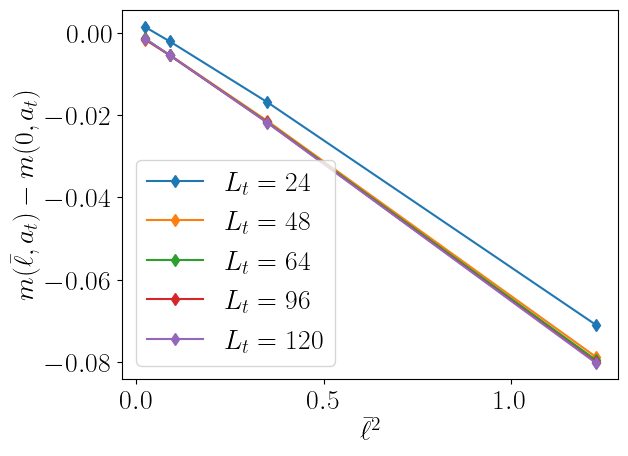

In [123]:
lim = fitter( [0.0, a_s[:4][0][1]], opt4[0][0], opt4[0][1], opt4[0][2] )
plt.plot( a_s[:4].T[0]**2, masses.T[2][:4]-lim, label="$L_t=24$", marker='d' )

lim = fitter( [0.0, a_s[4:8][0][1]], opt4[0][0], opt4[0][1], opt4[0][2] )
plt.plot( a_s[4:8].T[0]**2, masses.T[2][4:8]-lim, label="$L_t=48$", marker='d' )

lim = fitter( [0.0, a_s[8:12][0][1]], opt4[0][0], opt4[0][1], opt4[0][2] )
plt.plot( a_s[8:12].T[0]**2, masses.T[2][8:12]-lim, label="$L_t=64$", marker='d' )

lim = fitter( [0.0, a_s[12:16][0][1]], opt4[0][0], opt4[0][1], opt4[0][2] )
plt.plot( a_s[12:16].T[0]**2, masses.T[2][12:16]-lim, label="$L_t=96$", marker='d' )

lim = fitter( [0.0, a_s[16:][0][1]], opt4[0][0], opt4[0][1], opt4[0][2] )
plt.plot( a_s[16:].T[0]**2, masses.T[2][16:]-lim, label="$L_t=120$", marker='d' )

plt.legend()

plt.xlabel("$\\bar{\\ell}^2$")
plt.ylabel("$m(\\bar\\ell, a_t) - m(0, a_t)$")

# plt.savefig("m_ellbar.pdf", bbox_inches="tight")

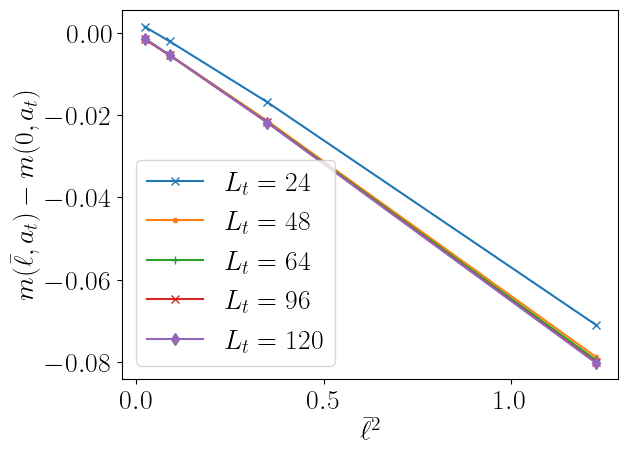

In [127]:
lim = fitter( [0.0, a_s[:4][0][1]], opt4[0][0], opt4[0][1], opt4[0][2] )
plt.plot( a_s[:4].T[0]**2, masses.T[2][:4]-lim, label="$L_t=24$", marker='x' )

lim = fitter( [0.0, a_s[4:8][0][1]], opt4[0][0], opt4[0][1], opt4[0][2] )
plt.plot( a_s[4:8].T[0]**2, masses.T[2][4:8]-lim, label="$L_t=48$", marker='.' )

lim = fitter( [0.0, a_s[8:12][0][1]], opt4[0][0], opt4[0][1], opt4[0][2] )
plt.plot( a_s[8:12].T[0]**2, masses.T[2][8:12]-lim, label="$L_t=64$", marker='+' )

lim = fitter( [0.0, a_s[12:16][0][1]], opt4[0][0], opt4[0][1], opt4[0][2] )
plt.plot( a_s[12:16].T[0]**2, masses.T[2][12:16]-lim, label="$L_t=96$", marker='x' )

lim = fitter( [0.0, a_s[16:][0][1]], opt4[0][0], opt4[0][1], opt4[0][2] )
plt.plot( a_s[16:].T[0]**2, masses.T[2][16:]-lim, label="$L_t=120$", marker='d' )

plt.legend()

plt.xlabel("$\\bar{\\ell}^2$")
plt.ylabel("$m(\\bar\\ell, a_t) - m(0, a_t)$")

plt.savefig("ellbar_scaling_gauge.pdf", bbox_inches="tight")

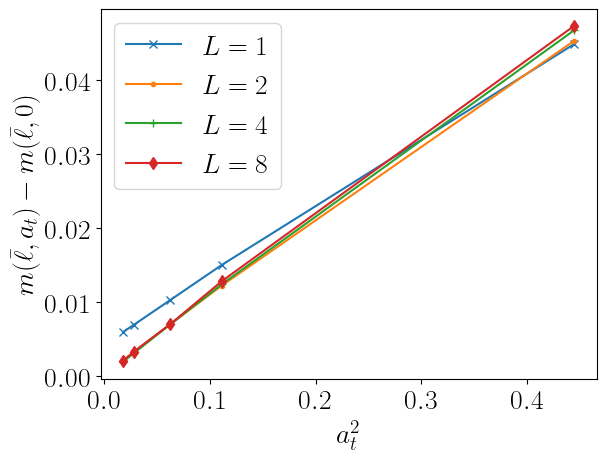

In [125]:
ibase=0
lim = fitter( [a_s[ibase::4][0][0], 0.0], opt4[0][0], opt4[0][1], opt4[0][2] )
plt.plot( a_s[ibase::4].T[1]**2, lim-masses.T[2][ibase::4], label="$L=1$", marker='x' )

ibase=1
lim = fitter( [a_s[ibase::4][0][0], 0.0], opt4[0][0], opt4[0][1], opt4[0][2] )
plt.plot( a_s[ibase::4].T[1]**2, lim-masses.T[2][ibase::4], label="$L=2$", marker='.' )

ibase=2
lim = fitter( [a_s[ibase::4][0][0], 0.0], opt4[0][0], opt4[0][1], opt4[0][2] )
plt.plot( a_s[ibase::4].T[1]**2, lim-masses.T[2][ibase::4], label="$L=4$", marker='+' )

ibase=3
lim = fitter( [a_s[ibase::4][0][0], 0.0], opt4[0][0], opt4[0][1], opt4[0][2] )
plt.plot( a_s[ibase::4].T[1]**2, lim-masses.T[2][ibase::4], label="$L=8$", marker='d' )

# plt.xscale("log")
# plt.yscale("log")
plt.legend()

plt.xlabel("$a_t^2$")
plt.ylabel("$m(\\bar\\ell, a_t) - m(\\bar\\ell, 0)$")

plt.savefig("at_scaling_gauge.pdf", bbox_inches="tight")

In [126]:
a_s

array([[1.10714872, 0.66666667],
       [0.59094644, 0.66666667],
       [0.29947447, 0.66666667],
       [0.15022749, 0.66666667],
       [1.10714872, 0.33333333],
       [0.59094644, 0.33333333],
       [0.29947447, 0.33333333],
       [0.15022749, 0.33333333],
       [1.10714872, 0.25      ],
       [0.59094644, 0.25      ],
       [0.29947447, 0.25      ],
       [0.15022749, 0.25      ],
       [1.10714872, 0.16666667],
       [0.59094644, 0.16666667],
       [0.29947447, 0.16666667],
       [0.15022749, 0.16666667],
       [1.10714872, 0.13333333],
       [0.59094644, 0.13333333],
       [0.29947447, 0.13333333],
       [0.15022749, 0.13333333]])

In [ ]:
fitter( [0.0, a_s[16:][0][1]], opt4[0][0], opt4[0][1], opt4[0][2] )

In [118]:
opt1[0][0]

1.4068732750000403

In [119]:
masses.T[2][::4]

array([1.2930765 , 1.32292346, 1.32765725, 1.33102841, 1.33197963])

In [120]:
a_s[::3].T[0]

array([1.10714872, 0.15022749, 0.29947447, 0.59094644, 1.10714872,
       0.15022749, 0.29947447])

In [121]:
a_s[4:8]

array([[1.10714872, 0.33333333],
       [0.59094644, 0.33333333],
       [0.29947447, 0.33333333],
       [0.15022749, 0.33333333]])

In [122]:
a_s

array([[1.10714872, 0.66666667],
       [0.59094644, 0.66666667],
       [0.29947447, 0.66666667],
       [0.15022749, 0.66666667],
       [1.10714872, 0.33333333],
       [0.59094644, 0.33333333],
       [0.29947447, 0.33333333],
       [0.15022749, 0.33333333],
       [1.10714872, 0.25      ],
       [0.59094644, 0.25      ],
       [0.29947447, 0.25      ],
       [0.15022749, 0.25      ],
       [1.10714872, 0.16666667],
       [0.59094644, 0.16666667],
       [0.29947447, 0.16666667],
       [0.15022749, 0.16666667],
       [1.10714872, 0.13333333],
       [0.59094644, 0.13333333],
       [0.29947447, 0.13333333],
       [0.15022749, 0.13333333]])

In [123]:
ibase=1

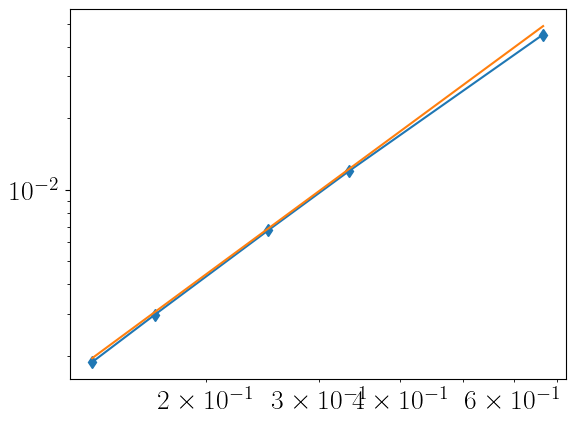

In [124]:
plt.plot( a_s[ibase::4].T[1], 1.3922-masses.T[2][ibase::4], label="$L_t=240$", marker='d' )

plt.plot( a_s[ibase::4].T[1], 0.11*a_s[ibase::4].T[1]**2, label="quad" )

plt.xscale("log")
plt.yscale("log")

In [125]:
ibase=2

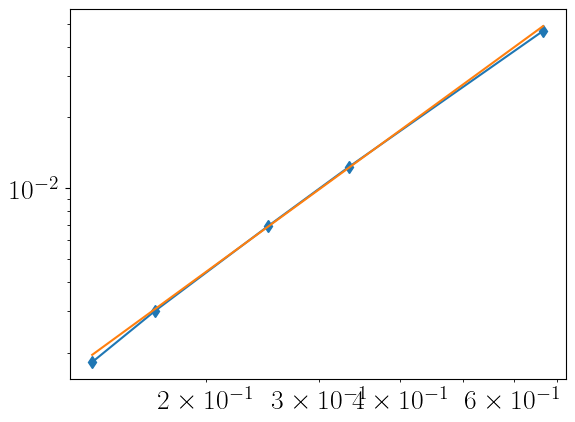

In [126]:
plt.plot( a_s[ibase::4].T[1], 1.4085-masses.T[2][ibase::4], label="$L_t=240$", marker='d' )

plt.plot( a_s[ibase::4].T[1], 0.11*a_s[ibase::4].T[1]**2, label="quad" )

plt.xscale("log")
plt.yscale("log")

In [127]:
ibase=3

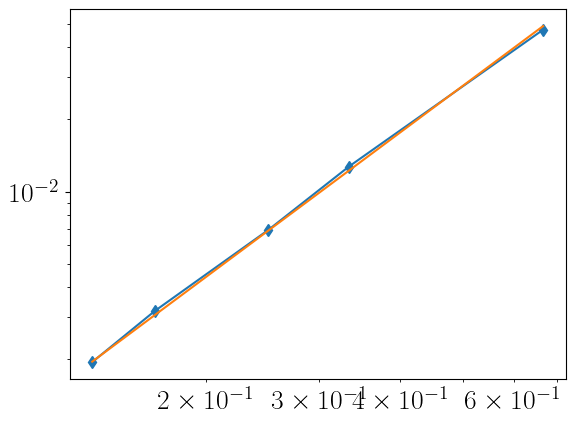

In [128]:
plt.plot( a_s[ibase::4].T[1], 1.41265-masses.T[2][ibase::4], label="$L_t=240$", marker='d' )

plt.plot( a_s[ibase::4].T[1], 0.11*a_s[ibase::4].T[1]**2, label="quad" )

plt.xscale("log")
plt.yscale("log")

In [129]:
a_s[3::4].T[1]

array([0.66666667, 0.33333333, 0.25      , 0.16666667, 0.13333333])

Text(0, 0.5, '$m$')

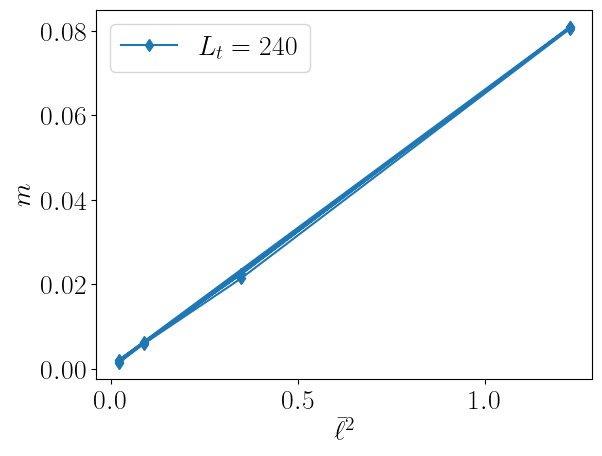

In [144]:
# plt.plot( a_s[:4].T[0], masses.T[2][:4], label="$L_t=96$", marker='x' )
# plt.plot( a_s[4:8].T[0], masses.T[2][4:8], label="$L_t=144$", marker='.' )
# plt.plot( a_s[8:12].T[0], masses.T[2][8:12], label="$L_t=192$", marker='o' )
plt.plot( a_s[12:].T[0]**2, np.sqrt(2.0)-masses.T[2][12:], label="$L_t=240$", marker='d' )

plt.legend()

# xxx=np.linspace( 0.0, 1.2, 100 )
# plt.plot( xxx, fitter([ xxx, np.full(100, a_s[0][1]) ], opt1[0][0], opt1[0][1], opt1[0][2] ), label="$L_t=96$", ls='dotted' )
# plt.plot( xxx, fitter([ xxx, np.full(100, a_s[4][1]) ], opt1[0][0], opt1[0][1], opt1[0][2] ), label="$L_t=144$", ls='dotted' )
# plt.plot( xxx, fitter([ xxx, np.full(100, a_s[7][1]) ], opt1[0][0], opt1[0][1], opt1[0][2] ), label="$L_t=192$", ls='dotted' )
# plt.plot( xxx, fitter([ xxx, np.full(100, a_s[10][1]) ], opt1[0][0], opt1[0][1], opt1[0][2] ), label="$L_t=240$", ls='dotted' )

# plt.xscale("log")
# plt.yscale("log")

# plt.hlines( np.sqrt(2.0), 0.0, 1.2, ls='dashed' )

plt.xlabel("$\\bar{\\ell}^2$")
plt.ylabel("$m$")

# plt.savefig("m_ellbar.pdf", bbox_inches="tight")

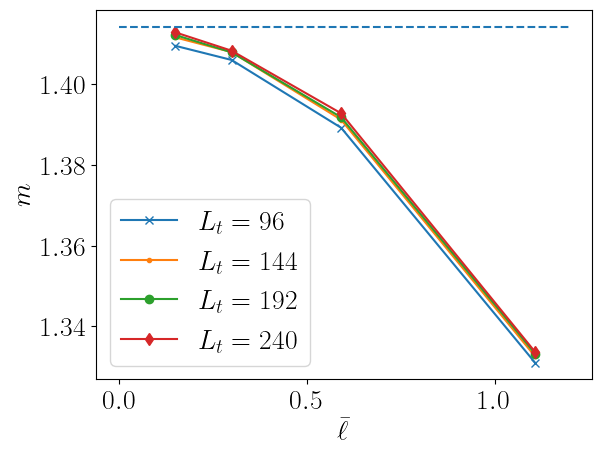

In [103]:
# plt.plot( a_s[:4].T[0], masses.T[2][:4], label="$L_t=96$", marker='x' )
# plt.plot( a_s[4:8].T[0], masses.T[2][4:8], label="$L_t=144$", marker='.' )
# plt.plot( a_s[8:12].T[0], masses.T[2][8:12], label="$L_t=192$", marker='o' )
# plt.plot( a_s[12:].T[0], masses.T[2][12:], label="$L_t=240$", marker='d' )

# plt.legend()

# # xxx=np.linspace( 0.0, 1.2, 100 )
# # plt.plot( xxx, fitter([ xxx, np.full(100, a_s[0][1]) ], opt1[0][0], opt1[0][1], opt1[0][2] ), label="$L_t=96$", ls='dotted' )
# # plt.plot( xxx, fitter([ xxx, np.full(100, a_s[4][1]) ], opt1[0][0], opt1[0][1], opt1[0][2] ), label="$L_t=144$", ls='dotted' )
# # plt.plot( xxx, fitter([ xxx, np.full(100, a_s[7][1]) ], opt1[0][0], opt1[0][1], opt1[0][2] ), label="$L_t=192$", ls='dotted' )
# # plt.plot( xxx, fitter([ xxx, np.full(100, a_s[10][1]) ], opt1[0][0], opt1[0][1], opt1[0][2] ), label="$L_t=240$", ls='dotted' )

# plt.hlines( np.sqrt(2.0), 0.0, 1.2, ls='dashed' )

# plt.xlabel("$\\bar{\\ell}$")
# plt.ylabel("$m$")

# plt.savefig("m_ellbar.pdf", bbox_inches="tight")

In [125]:
a_s[0][1]

0.16666666666666666